<a href="https://colab.research.google.com/github/Arifclasper/1/blob/statistic/Milestone_7_Simple_Linear_Regression_(Completed).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Task 1: Data Selection and Initial Visualization ---
Independent Variable (X): alcohol
Dependent Variable (Y): quality

Mean of X (alcohol): 9.70
Mean of Y (quality): 5.50
Variance of X: 0.13
Variance of Y: 0.72


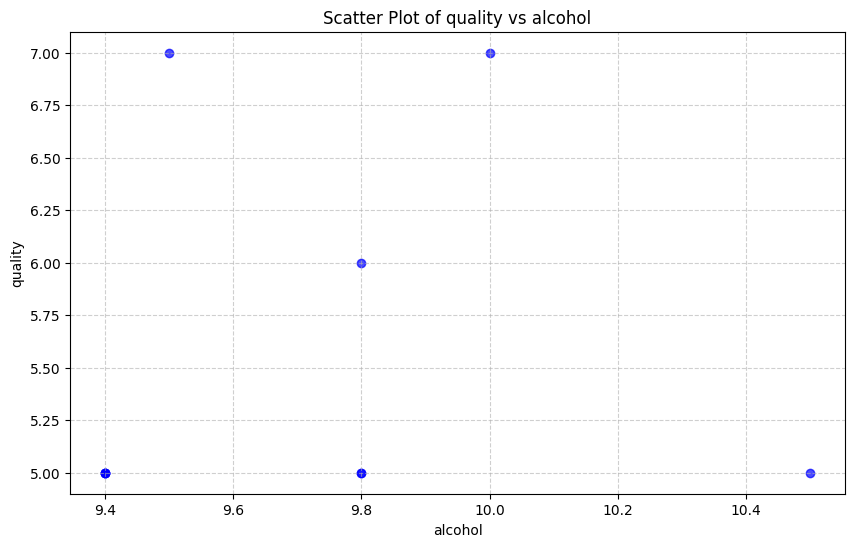

Numerator (Sum of products of deviations): 0.30
Denominator (Sum of squared deviations of X): 1.16

Computed Slope (β1): 0.2586
Computed Intercept (β0): 2.9914

Estimated Regression Equation: Ŷ = 2.9914 + 0.2586 * X


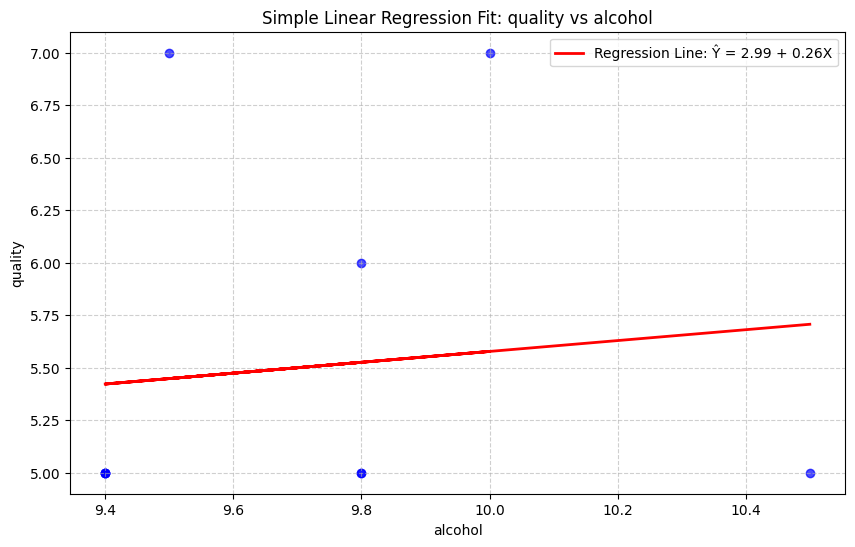

Pearson Correlation Coefficient (r): 0.1093
Coefficient of Determination (R²): 0.0119
Manual vs SKL Comparison:
Slope: 0.2586 | 0.2586
Intercept: 2.9914 | 2.9914
R²: 0.0119 | 0.0119

Reflect on the fit and parameters in your written report.


In [1]:
# ==============================================================================
# MILESTONE 7: SIMPLE LINEAR REGRESSION (MANUAL COMPUTATION) - WINE DATASET
# STA 2101: Statistics & Probability
#
# Objective: Calculate the parameters of the best-fit line (β0 and β1) and the
# correlation coefficient (r) using manual calculation methods.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DATA LOADING (Replace with actual CSV if needed) ---
data = {
    'fixed_acidity':[7.4,7.8,7.8,11.2,7.4,7.4,7.9,7.3,7.8,7.5],
    'volatile_acidity':[0.7,0.88,0.76,0.28,0.7,0.66,0.6,0.65,0.58,0.5],
    'citric_acid':[0,0,0.04,0.56,0,0,0.06,0,0.02,0.36],
    'residual_sugar':[1.9,2.6,2.3,1.9,1.9,1.8,1.6,1.2,2.0,6.1],
    'chlorides':[0.076,0.098,0.092,0.075,0.076,0.075,0.069,0.065,0.073,0.071],
    'free_sulfur_dioxide':[11,25,15,17,11,13,15,15,9,17],
    'total_sulfur_dioxide':[34,67,54,60,34,40,59,21,18,102],
    'density':[0.9978,0.9968,0.997,0.998,0.9978,0.9978,0.9964,0.9946,0.9968,0.9978],
    'pH':[3.51,3.2,3.26,3.16,3.51,3.51,3.3,3.39,3.36,3.35],
    'sulphates':[0.56,0.68,0.65,0.58,0.56,0.56,0.46,0.47,0.57,0.8],
    'alcohol':[9.4,9.8,9.8,9.8,9.4,9.4,9.4,10,9.5,10.5],
    'quality':[5,5,5,6,5,5,5,7,7,5],
    'style':['red']*10
}

df = pd.DataFrame(data)

# --- TASK 1: DATA SELECTION AND INITIAL VISUALIZATION ---
X = df['alcohol']
Y = df['quality']

print("--- Task 1: Data Selection and Initial Visualization ---")
print(f"Independent Variable (X): {X.name}")
print(f"Dependent Variable (Y): {Y.name}\n")

# Summary Statistics
X_mean = X.mean()
Y_mean = Y.mean()
X_var = X.var(ddof=1)
Y_var = Y.var(ddof=1)

print(f"Mean of X ({X.name}): {X_mean:.2f}")
print(f"Mean of Y ({Y.name}): {Y_mean:.2f}")
print(f"Variance of X: {X_var:.2f}")
print(f"Variance of Y: {Y_var:.2f}")

# Scatter Plot
plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='blue', alpha=0.7)
plt.title(f'Scatter Plot of {Y.name} vs {X.name}')
plt.xlabel(X.name)
plt.ylabel(Y.name)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- TASK 2: MANUAL CALCULATION OF REGRESSION PARAMETERS ---
X_dev = X - X_mean
Y_dev = Y - Y_mean

numerator_b1 = (X_dev * Y_dev).sum()
denominator_b1 = (X_dev**2).sum()

print(f"Numerator (Sum of products of deviations): {numerator_b1:.2f}")
print(f"Denominator (Sum of squared deviations of X): {denominator_b1:.2f}")

beta_1 = numerator_b1 / denominator_b1
beta_0 = Y_mean - beta_1 * X_mean

print(f"\nComputed Slope (β1): {beta_1:.4f}")
print(f"Computed Intercept (β0): {beta_0:.4f}")
print(f"\nEstimated Regression Equation: Ŷ = {beta_0:.4f} + {beta_1:.4f} * X")

# --- TASK 3: VISUALIZATION OF THE FIT ---
Y_pred = beta_0 + beta_1 * X

plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='blue', alpha=0.7)
plt.plot(X, Y_pred, color='red', linewidth=2, label=f'Regression Line: Ŷ = {beta_0:.2f} + {beta_1:.2f}X')
plt.title(f'Simple Linear Regression Fit: {Y.name} vs {X.name}')
plt.xlabel(X.name)
plt.ylabel(Y.name)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- TASK 4: STRENGTH OF RELATIONSHIP ---
sum_squared_deviations_Y = (Y_dev**2).sum()
denominator_r = np.sqrt(denominator_b1 * sum_squared_deviations_Y)

r = numerator_b1 / denominator_r
R_squared = r**2

print(f"Pearson Correlation Coefficient (r): {r:.4f}")
print(f"Coefficient of Determination (R²): {R_squared:.4f}")

# --- OPTIONAL: Verification with scikit-learn ---
try:
    from sklearn.linear_model import LinearRegression
    X_skl = X.values.reshape(-1,1)
    model = LinearRegression()
    model.fit(X_skl, Y)
    skl_beta_0 = model.intercept_
    skl_beta_1 = model.coef_[0]
    skl_R_squared = model.score(X_skl, Y)
    print(f"Manual vs SKL Comparison:\nSlope: {beta_1:.4f} | {skl_beta_1:.4f}\nIntercept: {beta_0:.4f} | {skl_beta_0:.4f}\nR²: {R_squared:.4f} | {skl_R_squared:.4f}")
except ImportError:
    print("scikit-learn not installed. Skipping verification.")

# --- TASK 5: REFLECTION ---
print("\nReflect on the fit and parameters in your written report.")
